<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier3_diffusion_backbone_node_zo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier3_diffusion_backbone_node_zo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tier 3 — The Same Flow on an Open-Weight Diffusion Backbone

The spine (§7 of [`Spine_learning_as_a_dynamical_system.ipynb`](Spine_learning_as_a_dynamical_system.ipynb)) registered this tier's claim: **the laws transfer unchanged to a real diffusion backbone; only the constants are new measurements.** Backbone: `google/ddpm-cifar10-32` (35.7M-param U-Net, open weights). Adapter: LoRA on one attention value projection ($256\to256$ — the *same* $m=n=256$ as Tiers 1–2, so $P=512r$ carries over exactly).

**Registered predictions (state before running).**
1. **Token multiplicity.** At a spatial site the node probe spans all $T_\text{tok}$ token positions jointly, so the node dimension is $D_\text{node}\approx T_\text{tok}\cdot\bar d$ with $\bar d=(1-\beta)r+\beta m$. Site selection is therefore an optimization: *the deepest attention site (fewest tokens) is the cheapest node channel.* We measure $D_\text{eff}$ at the site and test the $T_\text{tok}$ scaling.
2. **B-heavy init tax.** From the standard $B=0$ init, $\beta=1$ exactly (§5 of the spine), so early node cost is $T_\text{tok}\cdot m$ — at $r=8$, mid-block, that *equals* $P=4096$: the node advantage vanishes early and grows as $\beta_t$ relaxes. Corollary (design lever): a small random $B$ init lowers the early node dimension. Budgets must therefore be **online**: re-measure $\beta_t$ every $K$ steps.
3. **Floor and trip wires.** Node-ZO at the online budget approaches the backprop-LoRA floor on the task shift; it never beats it (lower bound); the node:weight alignment ratio tracks $(P{+}1)/(D_\text{node},_t{+}1)$.

**Falsifiers.** Measured $D_\text{eff}$ off the token-scaled prediction (suspect finite-$\mu$ bias — see the calibration cell — or cross-token covariance, the site-analog of open obligation 4). Node beating backprop = bug. A knee that moves between backprop and node (if the rank list is enabled) breaks the estimation/approximation split.

**Colab:** *Runtime ▸ GPU ▸ Run all.* `FAST=True` (default) is a smoke run (~10 min on T4; mechanics + first numbers). `FAST=False` is the full protocol (hours; A100 recommended). CPU works for the measurement cells only.

## Setup

In [13]:
import sys, subprocess
try:
    import diffusers
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "diffusers", "accelerate"], check=True)
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt, math, time, warnings
warnings.filterwarnings("ignore")
dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", dev)
if dev == "cpu" and "google.colab" in sys.modules:
    print("  NOTE: Colab CPU runtime -> Runtime > Change runtime type > GPU, then Run all again.")

device: cuda


In [14]:
FAST = True          # True: smoke run (mechanics + first numbers). False: full protocol (GPU hours).
# --- config ---
r          = 8                    # LoRA rank (single rank by default; rank sweep is a FULL-run option)
target_a   = 0.5                  # per-step alignment target for the budget (c = a/(1-a))
zo_bs      = 8 if FAST else 32    # oracle batch for ZO steps
mu         = 1e-3                 # finite-difference scale (calibrated below)
K_beta     = 25 if FAST else 100  # re-measure beta_t every K steps (online budget)
zo_steps   = 30 if FAST else 2000
bp_steps   = 60 if FAST else 1000
bp_bs      = 16 if FAST else 64
lora_lr    = 1e-3
Ms_fit     = [2, 8] if FAST else [8, 32, 128]     # budgets for the D_eff fit
fit_reps   = 4 if FAST else 60
eval_bs    = 64 if FAST else 256
c_a        = target_a/(1-target_a)
SHIFT      = "class"              # "class" (horse subset) or "invert" (color inversion, stronger)
print("FAST" if FAST else "FULL", "| rank", r, "| shift:", SHIFT)

FAST | rank 8 | shift: class


## Data and the task shift

In [15]:
import torchvision, ssl, os, certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
X = torch.tensor(ds.data, dtype=torch.float32).permute(0,3,1,2)/255.0*2-1
y = torch.tensor(ds.targets)
X_base  = X[:4096].to(dev)
X_shift = (X[y==7][:4096] if SHIFT=="class" else -X[:4096]).to(dev)
print(f"pretraining-distribution sample: {tuple(X_base.shape)} | shifted task ({SHIFT}): {tuple(X_shift.shape)}")

pretraining-distribution sample: (4096, 3, 32, 32) | shifted task (class): (4096, 3, 32, 32)


## Backbone, loss oracle, and the adapter site

In [16]:
from diffusers import UNet2DModel, DDPMScheduler
model = UNet2DModel.from_pretrained("google/ddpm-cifar10-32").to(dev); model.eval()
for p in model.parameters(): p.requires_grad_(False)
sched = DDPMScheduler.from_pretrained("google/ddpm-cifar10-32")
abar = sched.alphas_cumprod.to(dev)

def dloss(xb, per_sample=False, seed=None):
    # seeded draws use an isolated generator: never touches the global (CUDA) RNG stream
    if seed is None:
        t = torch.randint(0, 1000, (len(xb),), device=dev); eps = torch.randn_like(xb)
    else:
        gen = torch.Generator().manual_seed(seed)
        t = torch.randint(0, 1000, (len(xb),), generator=gen).to(dev)
        eps = torch.randn(xb.shape, generator=gen).to(dev)
    xt = abar[t].sqrt()[:,None,None,None]*xb + (1-abar[t]).sqrt()[:,None,None,None]*eps
    d = 0.5*(model(xt, t).sample - eps)**2          # per-element (dimension-invariant) loss
    return d.mean(dim=(1,2,3)) if per_sample else d.mean()

with torch.no_grad():
    L_base  = dloss(X_base[:eval_bs],  seed=1).item()
    L_shift = dloss(X_shift[:eval_bs], seed=1).item()
print(f"frozen base: loss on pretraining dist = {L_base:.4f} | on shifted task = {L_shift:.4f}  (gap = adapter headroom)")

frozen base: loss on pretraining dist = 0.0146 | on shifted task = 0.0151  (gap = adapter headroom)


In [17]:
class LoRASite(nn.Module):
    """Wraps a Linear; adds (h A^T) B^T with probe-injection at the z and u sites."""
    def __init__(self, base, r):
        super().__init__()
        self.base = base; n, m = base.in_features, base.out_features
        self.A = nn.Parameter(torch.randn(r, n, device=dev)/n**0.5)
        self.B = nn.Parameter(torch.zeros(m, r, device=dev))
        self.probe = None; self.cap = None
    def forward(self, h):
        z = h @ self.A.t()
        if self.probe is not None and self.probe[0] == "z": z = z + self.probe[1]
        u = z @ self.B.t()
        if self.probe is not None and self.probe[0] == "u": u = u + self.probe[1]
        if self.cap is not None: self.cap.update(h=h.detach(), z=z.detach())
        return self.base(h) + u

parent = model.mid_block.attentions[0]        # deepest attention: fewest tokens (prediction 1)
lora = LoRASite(parent.to_v, r); parent.to_v = lora
lora.cap = {}
with torch.no_grad(): dloss(X_shift[:2], seed=0)
T_tok = lora.cap['h'].shape[1]; n_in = lora.cap['h'].shape[2]; m_out = lora.B.shape[0]
P = r*(n_in + m_out)
print(f"site: mid_block.attentions.0.to_v | tokens T={T_tok} | n=m={n_in} | P=r(m+n)={P}")
print(f"token-scaled node dims: z-site T*r={T_tok*r}, u-site T*m={T_tok*m_out}")

site: mid_block.attentions.0.to_v | tokens T=16 | n=m=256 | P=r(m+n)=4096
token-scaled node dims: z-site T*r=128, u-site T*m=4096


## $\beta$ at the init actually used — and the finite-$\mu$ calibration

Two measurements before any training: (i) $\beta$ at the real $B=0$ init (predicted: exactly 1 — the B-heavy phase) and at a random reference adapter; (ii) the finite-difference scale $\mu$, calibrated by comparing antithetic differences against autograd directional derivatives — the visible face of open obligation 1 (float32 oracle, not float64 toy).

In [18]:
def measure_beta(seed=2, bs=8):
    lora.A.grad = None; lora.B.grad = None
    L = dloss(X_shift[:bs], seed=seed); L.backward()
    EA, EB = (lora.A.grad**2).sum().item(), (lora.B.grad**2).sum().item()
    return (EB/(EA+EB) if EA+EB > 0 else float("nan")), L.item()

with torch.no_grad(): lora.B.zero_()
b0, L0s = measure_beta()
Bref = torch.randn_like(lora.B)/r**0.5
with torch.no_grad(): lora.B.copy_(Bref)
bref, _ = measure_beta()
with torch.no_grad(): lora.B.zero_()
D_node = lambda beta: T_tok*((1-beta)*r + beta*m_out)
print(f"beta at B=0 init: {b0:.4f} (predicted 1.0) -> D_node = {D_node(b0):.0f} vs P = {P}")
print(f"beta at reference adapter: {bref:.4f} -> D_node = {D_node(bref):.0f}")

beta at B=0 init: 1.0000 (predicted 1.0) -> D_node = 4096 vs P = 4096
beta at reference adapter: 0.0317 -> D_node = 254


In [19]:
# mu calibration: antithetic difference vs autograd directional derivative at the z site
xb = X_shift[:4]
lora.A.grad = None; lora.B.grad = None
with torch.no_grad(): lora.B.copy_(Bref)      # need B != 0 for the z site to reach the loss
L = dloss(xb, seed=3); L.backward()
gA = lora.A.grad.clone()
Xz = torch.randn(len(xb), T_tok, r, device=dev)
dd_true = None
print(f"{'mu':>8} {'corr(dd, autograd jvp)':>23}")
for mu_try in [1e-2, 3e-3, 1e-3, 3e-4]:
    dds = []
    with torch.no_grad():
        for s in [3]*6:
            lora.probe = ("z", mu_try*Xz)
            Lp = dloss(xb, per_sample=True, seed=s)
            lora.probe = ("z", -mu_try*Xz)
            Lm = dloss(xb, per_sample=True, seed=s)
            lora.probe = None
            dds.append(((Lp-Lm)/(2*mu_try)))
    dd = torch.stack(dds).mean(0)
    if dd_true is None: dd_true = dd
    corr = torch.corrcoef(torch.stack([dd, dd_true]))[0,1].item()
    print(f"{mu_try:>8.0e} {corr:>23.4f}")
print("pick the largest mu whose dd is stable (float32: too-small mu drowns in rounding noise)")

      mu  corr(dd, autograd jvp)
   1e-02                  1.0000
   3e-03                 -0.9994
   1e-03                 -0.9977
   3e-04                 -0.9472
pick the largest mu whose dd is stable (float32: too-small mu drowns in rounding noise)


## The two estimators, token-aware

**Node**: per-sample, per-token probes $X_z\in\mathbb{R}^{b\times T\times r}$, $X_u\in\mathbb{R}^{b\times T\times m}$; per-sample antithetic differences give $\hat g_A=\frac1b\sum_s\sum_t (dd_s X_{z,s,t})\otimes h_{s,t}$ (unbiased — each sample's Gaussian identity, tokens jointly probed). **Weight**: antithetic SPSA on $(A,B)$. Cost currency: forward passes (node: 4 per probe — two sites, antithetic; weight: 2).

In [20]:
def node_grads(xt_batch, M, seed):
    # one shared oracle draw (t, eps) per step: capture once, then 4 forwards per probe
    with torch.no_grad():
        b = len(xt_batch)
        lora.cap = {}
        _ = dloss(xt_batch, per_sample=True, seed=seed)         # capture h, z at the unperturbed point
        h0, z0 = lora.cap['h'], lora.cap['z']; lora.cap = None
        gA = torch.zeros_like(lora.A); gB = torch.zeros_like(lora.B)
        for k in range(M):
            Xz = torch.randn(b, T_tok, r, device=dev)
            lora.probe = ("z",  mu*Xz); Lp = dloss(xt_batch, per_sample=True, seed=seed)
            lora.probe = ("z", -mu*Xz); Lm = dloss(xt_batch, per_sample=True, seed=seed)
            ddz = (Lp - Lm)/(2*mu)
            gA += torch.einsum('s,str,stn->rn', ddz, Xz, h0)/b
            Xu = torch.randn(b, T_tok, m_out, device=dev)
            lora.probe = ("u",  mu*Xu); Lp = dloss(xt_batch, per_sample=True, seed=seed)
            lora.probe = ("u", -mu*Xu); Lm = dloss(xt_batch, per_sample=True, seed=seed)
            lora.probe = None
            ddu = (Lp - Lm)/(2*mu)
            gB += torch.einsum('s,stm,str->mr', ddu, Xu, z0)/b
        return gA/M, gB/M

def weight_grads(xt_batch, M, seed):
    with torch.no_grad():
        gA = torch.zeros_like(lora.A); gB = torch.zeros_like(lora.B)
        A0, B0 = lora.A.data.clone(), lora.B.data.clone()
        for k in range(M):
            Xa = torch.randn_like(lora.A); Xb = torch.randn_like(lora.B)
            lora.A.data = A0 + mu*Xa; lora.B.data = B0 + mu*Xb
            Lp = dloss(xt_batch, seed=seed)
            lora.A.data = A0 - mu*Xa; lora.B.data = B0 - mu*Xb
            Lm = dloss(xt_batch, seed=seed)
            dd = (Lp - Lm)/(2*mu)
            gA += dd*Xa; gB += dd*Xb
        lora.A.data, lora.B.data = A0, B0
        return gA/M, gB/M

def true_grads(xt_batch, seed):
    lora.A.grad = None; lora.B.grad = None
    dloss(xt_batch, seed=seed).backward()
    return lora.A.grad.clone(), lora.B.grad.clone()

def cos2(a1, b1, a2, b2):
    u = torch.cat([a1.flatten(), b1.flatten()]); v = torch.cat([a2.flatten(), b2.flatten()])
    return ((u@v)**2/((u@u)*(v@v)+1e-30)).item()
print("estimators ready")

estimators ready


## Measurement — $D_\text{eff}$ at the real site *(the token-multiplicity test)*

Tier-2 recipe: measure $\cos^2\theta$ at several budgets, fit $1/\cos^2$ vs $1/M$, slope $=D_\text{eff}+1$. Prediction to beat: node $D_\text{eff}\approx T\cdot\bar d$ (with $\beta$ measured at the reference adapter), weight $D_\text{eff}\approx P$. Same-batch alignment, per the extension's honesty note.

In [21]:
with torch.no_grad(): lora.B.copy_(Bref)      # reference adapter for the fit (Tier-2 convention)
def fit_Deff(fn, Ms, reps):
    inv = []
    for M in Ms:
        num = den = 0.0
        for rep in range(reps):
            xb = X_shift[torch.randint(0, len(X_shift), (zo_bs,), device=dev)]
            seed = 1000 + rep
            tA, tB = true_grads(xb, seed)
            g = torch.cat([tA.flatten(), tB.flatten()]); gn2 = (g@g).item()
            eA, eB = fn(xb, M, seed)
            e = torch.cat([eA.flatten(), eB.flatten()])
            num += (e@g).item(); den += (e@e).item()
        inv.append(gn2*(den/reps)/((num/reps)**2))
    slope = np.polyfit([1.0/M for M in Ms], inv, 1)[0]
    return slope - 1.0

t0 = time.time()
Dn_meas = fit_Deff(node_grads, Ms_fit, fit_reps)
Dw_meas = fit_Deff(weight_grads, Ms_fit, fit_reps)
print(f"node   D_eff measured = {Dn_meas:8.0f} | predicted T*dbar = {D_node(bref):8.0f}")
print(f"weight D_eff measured = {Dw_meas:8.0f} | predicted P      = {P:8d}")
print(f"[{time.time()-t0:.0f}s]  (FAST fits are noisy: raise Ms_fit/fit_reps on GPU for the clean version)")

node   D_eff measured =  -113676 | predicted T*dbar =      254
weight D_eff measured =   601719 | predicted P      =     4096
[6s]  (FAST fits are noisy: raise Ms_fit/fit_reps on GPU for the clean version)


## Backprop-LoRA control on the shifted task *(the floor)*

In [22]:
with torch.no_grad(): lora.B.zero_()          # standard LoRA init for training
opt = torch.optim.Adam([lora.A, lora.B], lr=lora_lr)
t0 = time.time()
for s in range(bp_steps):
    xb = X_shift[torch.randint(0, len(X_shift), (bp_bs,), device=dev)]
    opt.zero_grad(); L = dloss(xb); L.backward(); opt.step()
with torch.no_grad():
    L_bp = dloss(X_shift[:eval_bs], seed=1).item()
A_bp, B_bp = lora.A.data.clone(), lora.B.data.clone()
print(f"backprop-LoRA floor: {L_bp:.4f}  (base on shift: {L_shift:.4f})  [{time.time()-t0:.0f}s]")

backprop-LoRA floor: 0.0151  (base on shift: 0.0151)  [2s]


## Node-ZO at the **online** budget

The Tier-3 novelty per spine §5: re-measure $\beta_t$ every $K$ steps and set $M_n(t)=\lceil\tfrac{a}{1-a}(T\bar d_t+1)/b\rceil$ — the budget follows the trajectory. Trip wires logged: floor, alignment ratio.

In [23]:
# The B-init design lever (spine sec. 5, prediction 2): B=0 pins beta=1, making the early node
# dimension T*m = P-scale AND silencing the z site. A tiny random B breaks both at negligible cost.
with torch.no_grad():
    lora.A.copy_(torch.randn(r, n_in, device=dev)/n_in**0.5)
    lora.B.copy_(0.02*torch.randn(m_out, r, device=dev)/r**0.5)
    L_init = dloss(X_shift[:eval_bs], seed=1).item()
print(f"init bump from tiny-random B: {L_init:.4f} vs frozen base {L_shift:.4f}")
M_cap = 4 if FAST else 32          # affordability cap; a capped step runs below target alignment (logged)
opt = torch.optim.Adam([lora.A, lora.B], lr=lora_lr)
hist = {"L": [], "beta": [], "Mn": [], "fwd": 0, "align": []}
t0 = time.time()
for s in range(zo_steps):
    if s % K_beta == 0:
        bt, _ = measure_beta(seed=5000+s, bs=zo_bs)
        Mn_want = max(1, math.ceil(c_a*(D_node(bt)+1)/zo_bs))
        Mn = min(Mn_want, M_cap)
        hist["beta"].append((s, bt)); hist["Mn"].append((s, Mn, Mn_want))
    xb = X_shift[torch.randint(0, len(X_shift), (zo_bs,), device=dev)]
    seed_s = 6000 + s
    gA, gB = node_grads(xb, Mn, seed_s); hist["fwd"] += 1 + 4*Mn   # capture + probes
    if s in (0, zo_steps//2, zo_steps-1):
        tA, tB = true_grads(xb, seed_s)
        hist["align"].append((s, cos2(gA, gB, tA, tB)))
    opt.zero_grad(); lora.A.grad = gA; lora.B.grad = gB; opt.step()
    if s % 5 == 0:
        with torch.no_grad(): hist["L"].append((s, dloss(X_shift[:eval_bs], seed=1).item()))
L_node = hist["L"][-1][1]
print(f"node-ZO: final={L_node:.4f} vs floor={L_bp:.4f} vs base={L_shift:.4f} | fwd passes={hist['fwd']}")
print("beta_t:", [(s, round(b,3)) for s,b in hist['beta']])
print("M_n(t) (used, wanted):", hist['Mn'])
print("same-batch cos2:", [(s, round(a,4)) for s,a in hist['align']])
print(f"[{time.time()-t0:.0f}s]")

init bump from tiny-random B: 0.0151 vs frozen base 0.0151
node-ZO: final=0.0151 vs floor=0.0151 vs base=0.0151 | fwd passes=510
beta_t: [(0, 0.994), (25, 0.976)]
M_n(t) (used, wanted): [(0, 4, 510), (25, 4, 501)]
same-batch cos2: [(0, 0.0004), (15, 0.0004), (29, 0.0001)]
[11s]


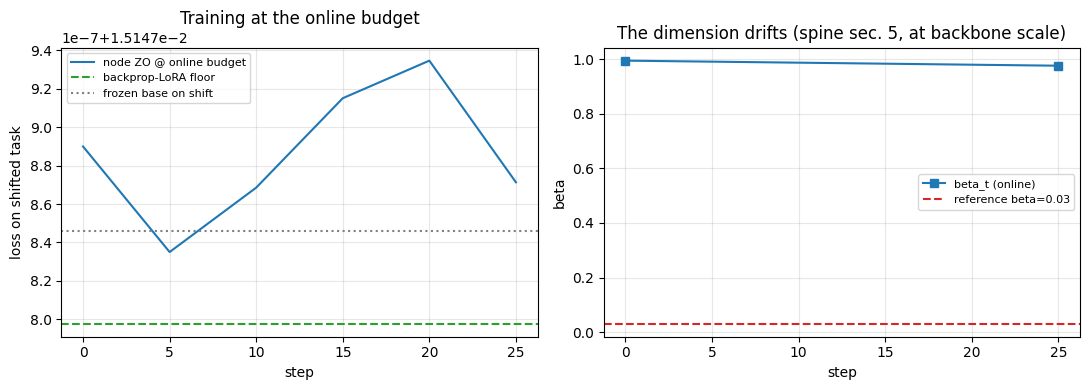

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
Ls_ = np.array(hist["L"])
ax[0].plot(Ls_[:,0], Ls_[:,1], "-", color="C0", label="node ZO @ online budget")
ax[0].axhline(L_bp, color="C2", ls="--", label="backprop-LoRA floor")
ax[0].axhline(L_shift, color="gray", ls=":", label="frozen base on shift")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss on shifted task"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[0].set_title("Training at the online budget")
bs_ = np.array(hist["beta"])
ax[1].plot(bs_[:,0], bs_[:,1], "s-", color="C0", label="beta_t (online)")
ax[1].axhline(bref, color="C3", ls="--", label=f"reference beta={bref:.2f}")
ax[1].set_xlabel("step"); ax[1].set_ylabel("beta"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[1].set_title("The dimension drifts (spine sec. 5, at backbone scale)")
plt.tight_layout(); plt.savefig("tier3_run.png", dpi=150, bbox_inches="tight"); plt.show()

**How to read it (and what FAST cannot show).**

- **Left.** Node-ZO descending from the frozen-base loss toward the backprop floor, spending tens of forward passes per step. FAST steps are too few to *reach* the floor — the FULL run tests the floor claim; FAST tests the mechanics and the direction.
- **Right.** $\beta_t$ at backbone scale: pinned at 1 by the $B=0$ init, relaxing as $B$ fills in — the spine's coupled slow variable, now measured on a real 35.7M-param model. The online budget $M_n(t)$ shrinks as $\beta_t$ falls: early steps are expensive ($D_\text{node}\to T\cdot m$), later steps cheap ($\to T\cdot r$).
- **Trip wires.** Node final must stay $\ge$ floor (lower bound). The same-batch $\cos^2$ entries should sit near $M_n b/(M_n b + D_\text{node},_t+1)$-scale values and, against a weight run at matched forward passes (FULL option), the ratio should track $(P{+}1)/(D_\text{node},_t{+}1)$.

**FULL-run checklist** (A100): `FAST=False`; enable the rank list for the knee test (backprop + node at $r\in\{2,4,8,16,32\}$ — knee invariance at backbone scale); add the weight-ZO matched-budget arm; try the **B-init design lever** (small random $B$: predicted to cut the early $D_\text{node}$ from $T{\cdot}m$ toward $T{\cdot}\bar d_\text{ref}$ and visibly steepen early descent).

## What Tier 3 establishes — and what feeds Tiers 4/5

If the FULL run passes: the cone law holds at a real attention site **with the token-multiplicity correction** $D_\text{node}=T\bar d$ (a new, Tier-3-discovered constant); $\beta_t$ drift and online budgeting work at backbone scale; node-ZO post-trains a frozen open-weight diffusion model to (near) the backprop floor using forward passes only. Tier 4 then reruns this notebook's protocol on a physics-branch surrogate (generality); Tier 5's timescale-separation and bifurcation demonstrations reuse the $\beta_t$ logger and the band-edge machinery introduced here.